In [58]:
import os
import sys
import cv2
import numpy as np
from tqdm import tqdm
import kagglehub

In [59]:
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria


In [61]:
RAW_DIR = os.path.join(path, "cell_images", "cell_images")
print("Using RAW_DIR:", RAW_DIR)
print(os.listdir(RAW_DIR))

Using RAW_DIR: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images
['Uninfected', 'Parasitized']


In [62]:
SRC_PATH = "/kaggle/input/datasets/priyanshusghosh/source/src"
sys.path.append(SRC_PATH)

In [63]:
from data.loader import load_image_paths, read_image
from data.preprocessing import preprocess_image

In [64]:
PROCESSED_DIR = "/kaggle/working/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [65]:
data = load_image_paths(RAW_DIR)
print("Total images:", len(data))

Total images: 27560


In [66]:
CLASS_NAMES = ["Parasitized", "Uninfected"]

for cls in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_DIR, cls), exist_ok=True)

In [67]:
for img_path, label in tqdm(data):
    try:
        img = read_image(img_path)
        processed = preprocess_image(img)

        filename = os.path.basename(img_path)
        class_name = CLASS_NAMES[label]

        save_path = os.path.join(PROCESSED_DIR, class_name, filename)

        cv2.imwrite(save_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))

    except Exception as e:
        print("Error:", img_path)

 33%|███▎      | 9220/27560 [02:51<05:11, 58.86it/s]

Error: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized/Thumbs.db


 83%|████████▎ | 22924/27560 [07:02<01:39, 46.75it/s]

Error: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected/Thumbs.db


100%|██████████| 27560/27560 [08:28<00:00, 54.15it/s]


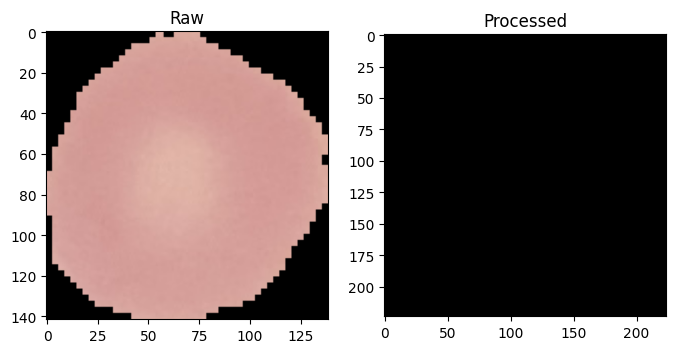

In [77]:
import matplotlib.pyplot as plt

sample_path, _ = data[18920]

raw = read_image(sample_path)
proc = preprocess_image(raw)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(raw)
plt.title("Raw")

plt.subplot(1,2,2)
plt.imshow(proc)
plt.title("Processed")

plt.show()

In [78]:
import shutil

shutil.make_archive(
    "/kaggle/working/processed",  # output zip (without .zip)
    'zip',
    "/kaggle/working/processed"
)

'/kaggle/working/processed.zip'